# **Logistic Regression:**

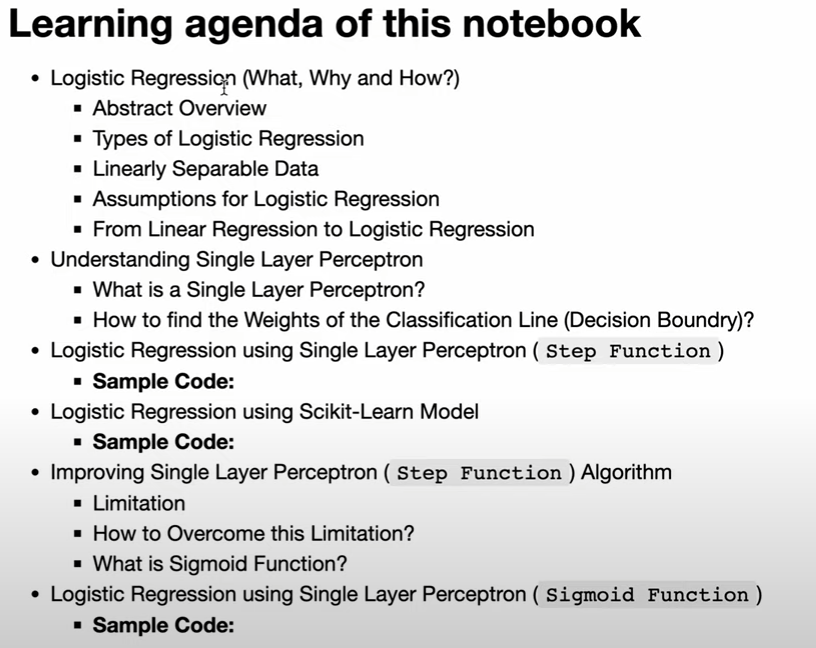

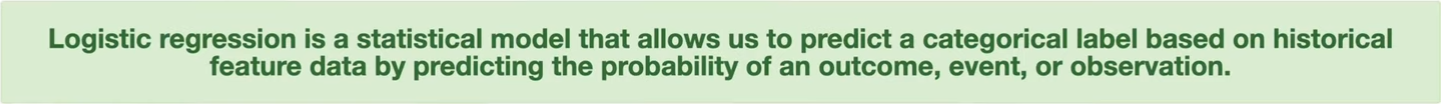

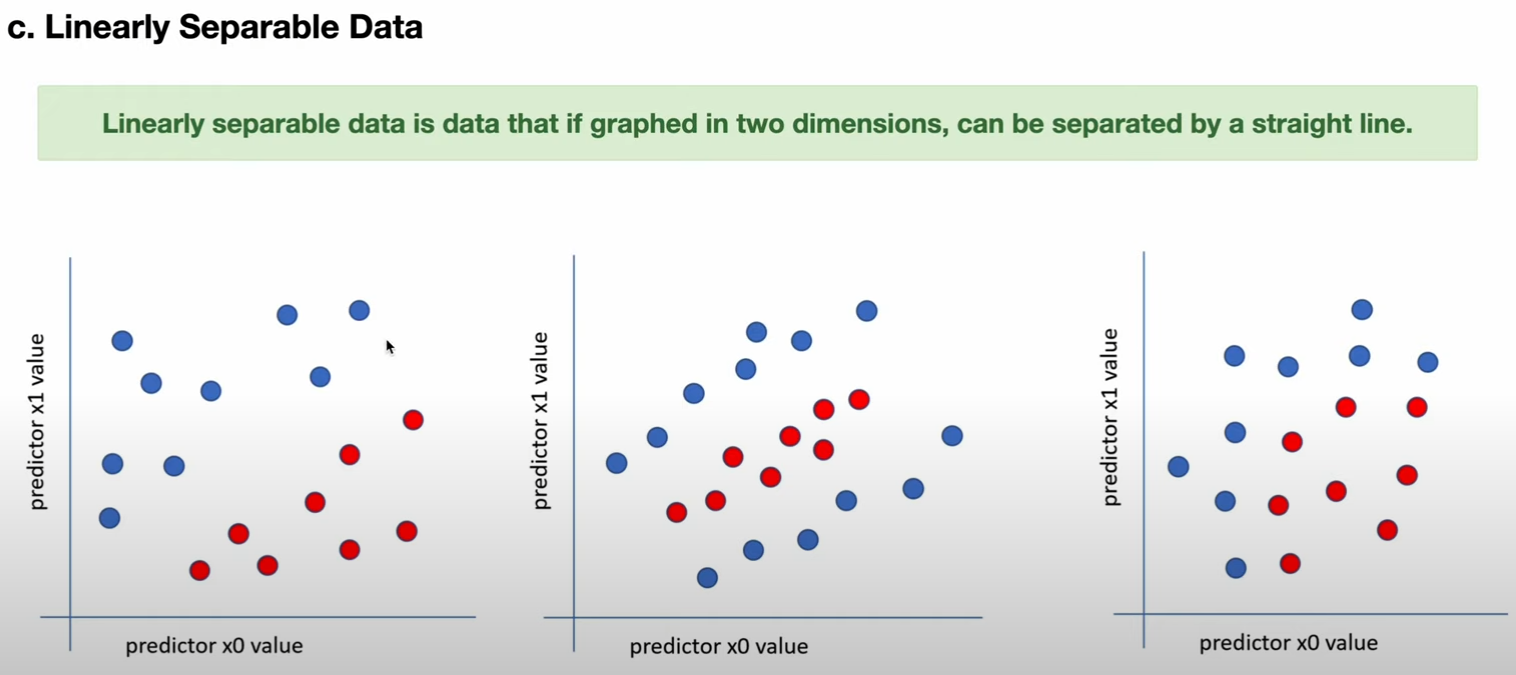

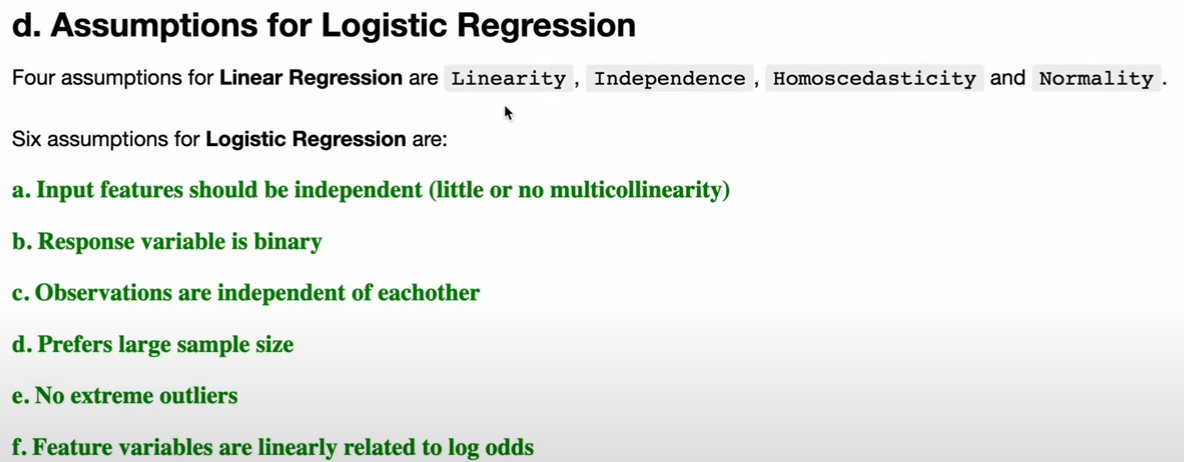

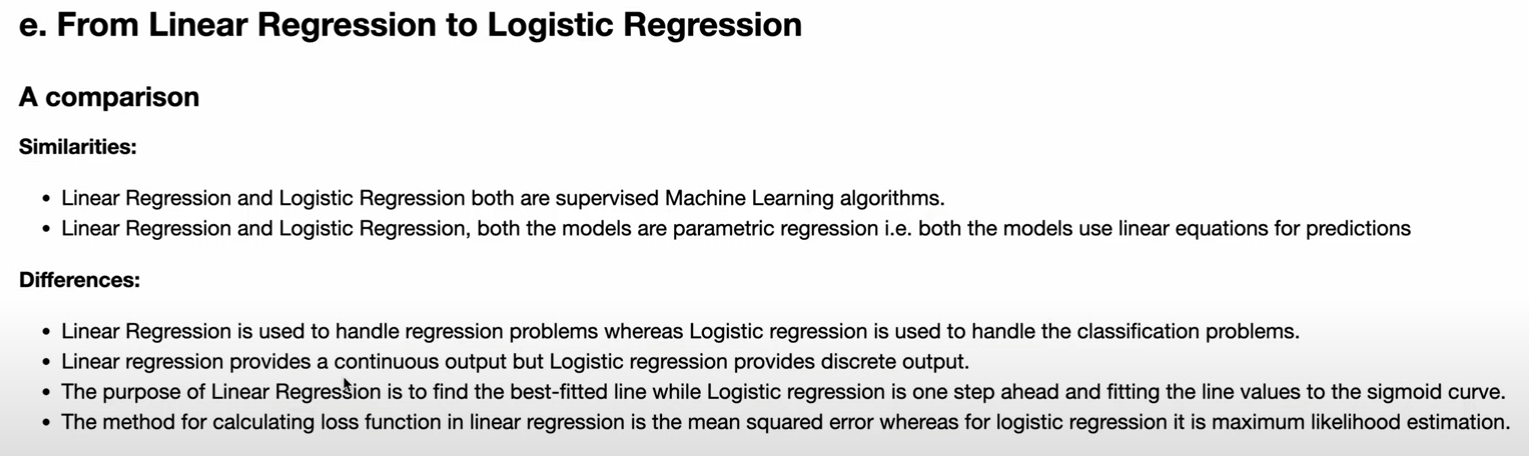

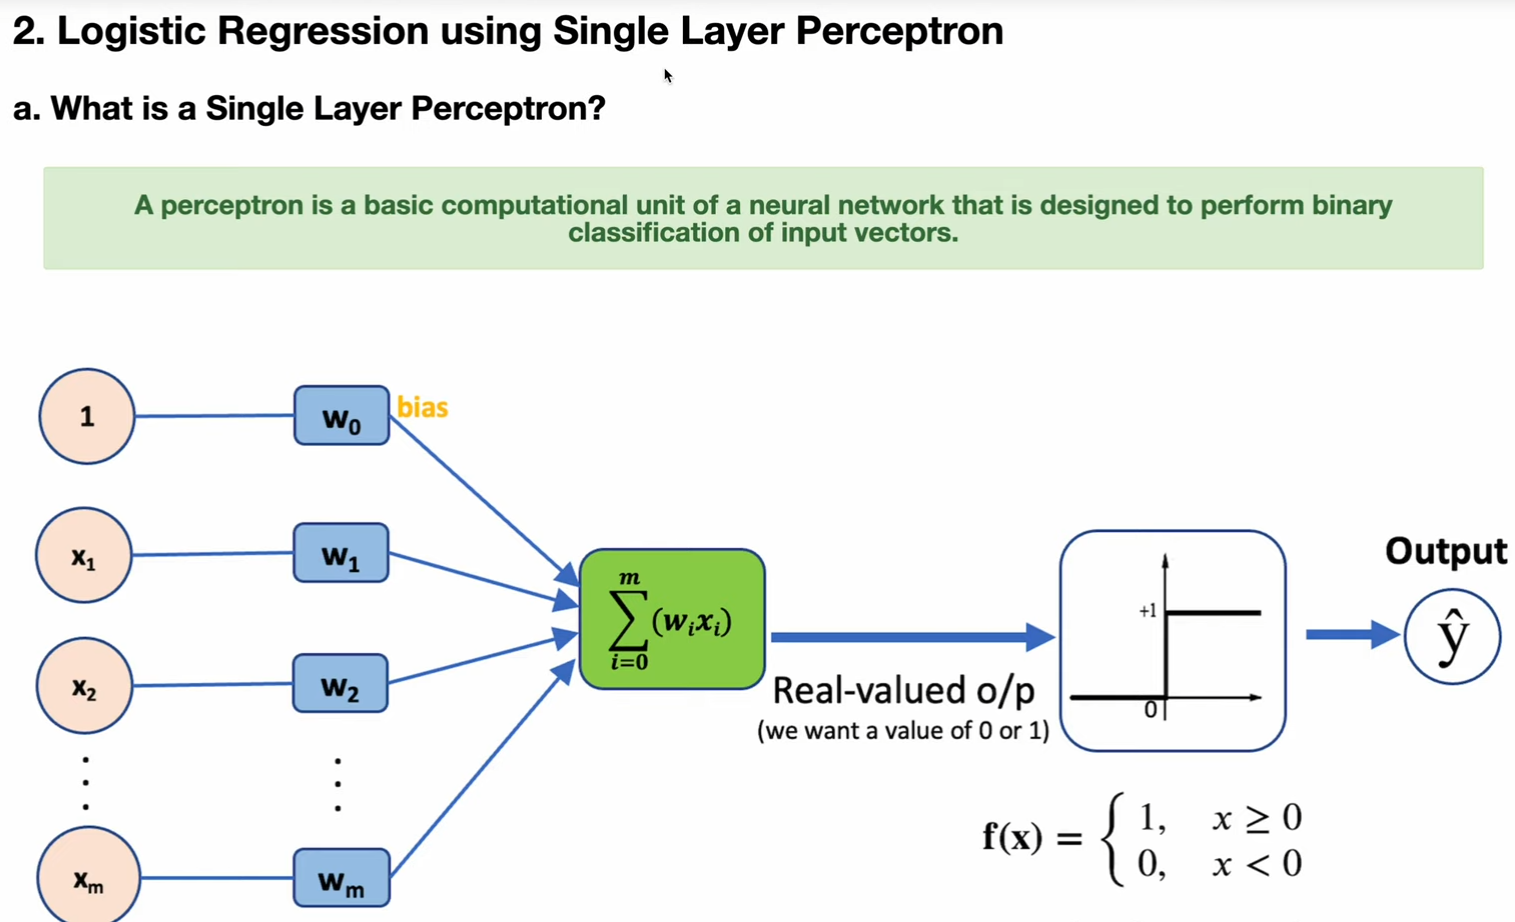

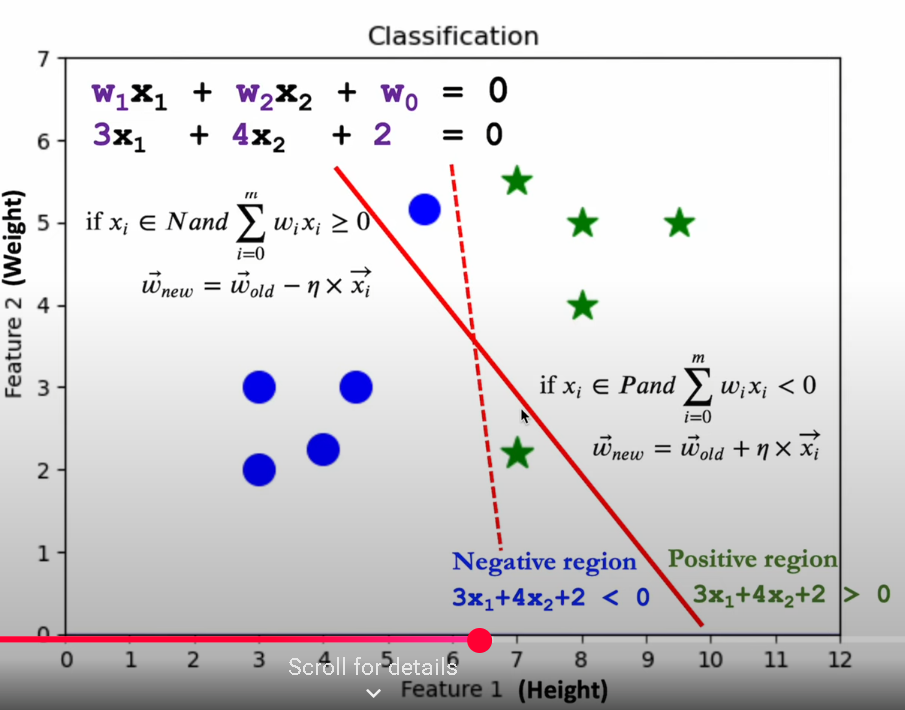

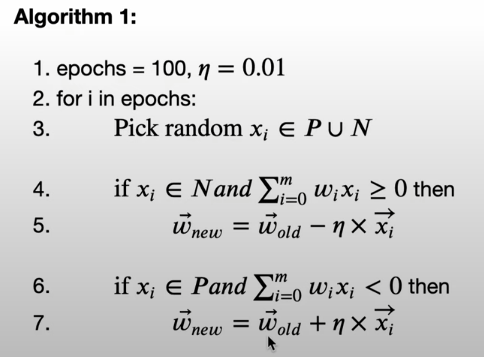

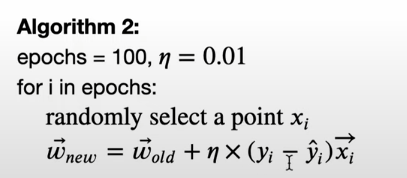

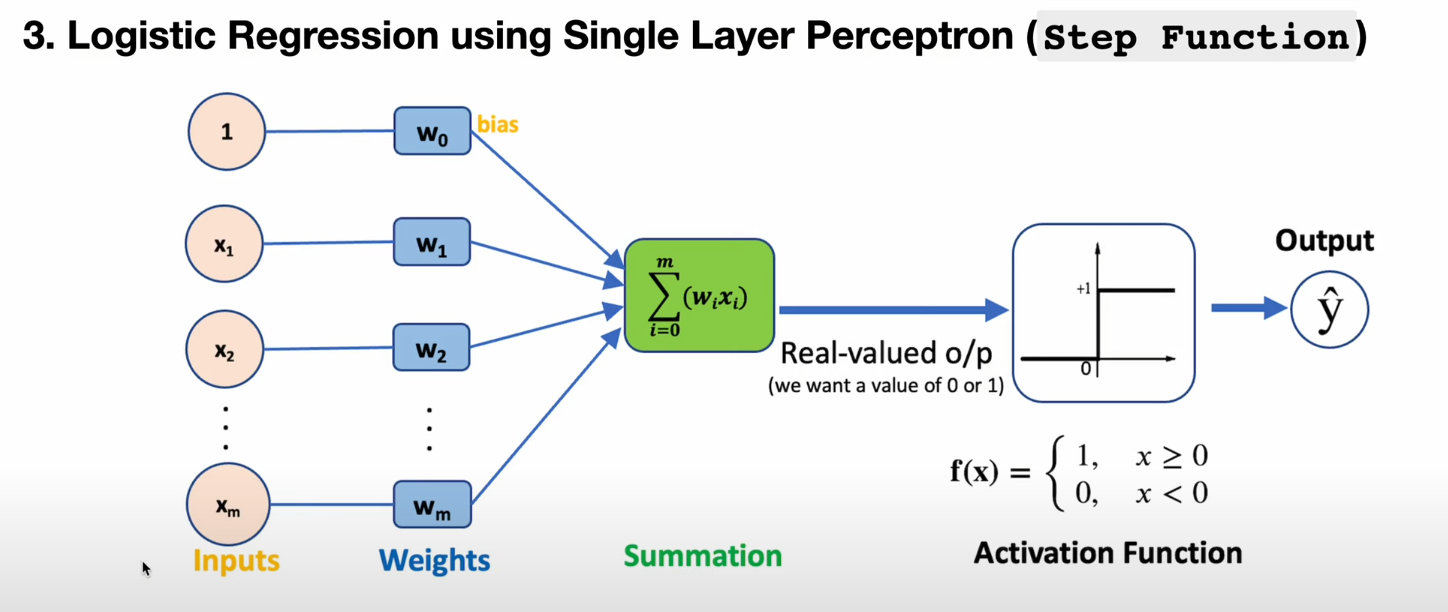

In [11]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=20,
    random_state=41,
    n_informative=1,
    n_redundant=0,
    hypercube=False
)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (100, 2)
y shape: (100,)


In [12]:
X[0:5]

array([[ 0.51123145, -0.11697552],
       [ 0.06316371, -0.73115232],
       [-0.0425064 , -0.7081059 ],
       [-3.2891569 , -2.01199214],
       [ 0.1111445 ,  1.63493163]])

In [13]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

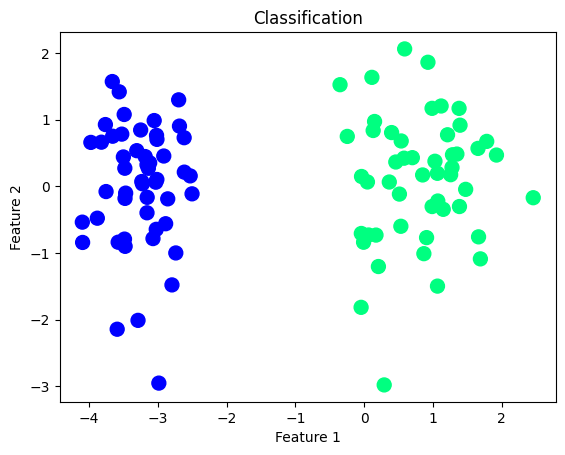

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

plt.title("Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

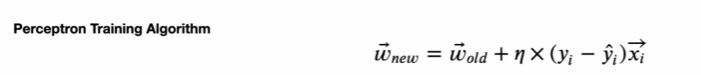

In [ ]:
# def step(z):
#     return 1 if z > 0 else 0
    
# def perceptron(X, y):
#     X = np.insert(X, 0, 1, axis=1)
#     weights = np.ones(X.shape[1])
#     lr = 1.0 # ?                      learning Rate: controls how much the weights change during each update.
#     epocs = 1000
#     for i in range(epocs):
#         j = np.random.randint(0, 100)
#         y_hat = step(np.sum( np.dot( X[j], weights) ) )  # y_head
#         weights = weights + lr * (y[j] - y_hat) * X[j]
    
#     return weights[0], weights[1:]
        
def perceptron(X, y):
    # Add bias term (column of 1s at index 0)
    X = np.insert(X, 0, 1, axis=1)
    
    # Initialize weights (including bias weight)
    weights = np.ones(X.shape[1])
    
    lr = 0.1  # Learning rate
    epocs = 1000  # Number of iterations
    
    for i in range(epocs):
        # Pick a random sample index
        j = np.random.randint(0, 100)
        
        # Compute prediction
        y_hat = step(np.sum(np.dot(X[j], weights)))
        
        # Update weights
        weights = weights + lr * (y[j] - y_hat) * X[j]
    
    # Return bias weight and feature weights separately
    return weights[0], weights[1:]


In [47]:
bias, weights = perceptron(X, y)
print("w0: ", bias)
print("w1 and w2: ", weights)

w0:  1.3000000000000003
w1 and w2:  [1.05343617 0.2221512 ]


**Result:**

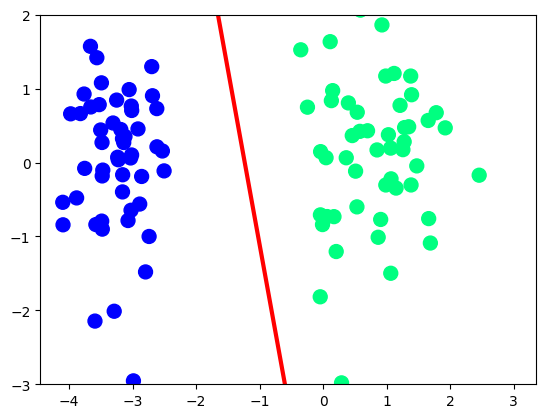

In [50]:
# m = -(weights[0]/weights[1])
# b = -(bias/weights[1])
# x_input = np.linspace(-3,3,100)
# y_input = m *x_input + b

# plt.plot(x_input, y_input, color="red", linewidth=3)
# plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s=100)
# plt.show()


# Assume weights and bias are returned from perceptron()
# weights[0] is bias, weights[1:] is feature weights

# Calculate slope (m) and intercept (b) for decision boundary
m = -(weights[0] / weights[1])
b = -(bias / weights[1])

# Generate x values from -3 to 3
x_input = np.linspace(-3, 3, 100)

# Compute corresponding y values for the decision boundary line
y_input = m * x_input + b

# Plot decision boundary
plt.plot(x_input, y_input, color='red', linewidth=3)

# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

# Set y-axis limits
plt.ylim(-3, 2)

# Show the plot
plt.show()


In [51]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [52]:
print("w0: ", model.intercept_)
print("w1 and w2: ", model.coef_)

w0:  [3.13571596]
w1 and w2:  [[2.36679363 0.02300492]]


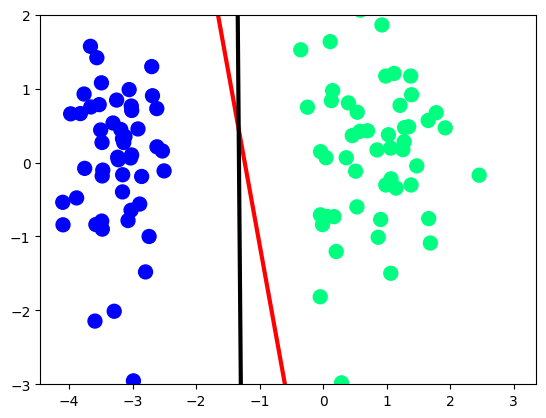

In [ ]:
m = -(model.coef_[0][0]/model.coef_[0][1])
b = -(model.intercept_/model.coef_[0][1])




# Generate x values from -3 to 3
x_input1 = np.linspace(-3, 3, 100)

y_input1 = m * x_input + b

plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

plt.ylim(-3, 2)

# Show the plot
plt.show()